In [1]:
%pip install numpy
%pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import numpy as np
from collections import deque

def cap_size(filament):
    count = 0
    for sub in reversed(filament):
        if sub in ["ATP", "ADP-Pi"]:
            count += 1
        else:
            break
    return count

def run_simulation(t_end, r1, r2, r3, r4, r5, r6, r7, r8, r_exch, r_hydrol, r_pi_rel, seed_number, G_ATP_i, G_ADP_i, vol):

  t = 0
  G_ATP = G_ATP_i
  G_ADP = G_ADP_i
  filaments = [deque(['ATP','ATP','ATP','ATP','ATP','ATP','ATP','ATP','ATP','ATP','ATP''ATP','ATP','ATP','ATP','ATP','ATP','ATP','ATP','ATP','ATP','ATP']) for _ in range(seed_number)]

  #-- Flux --
  plus_add = 0
  plus_loss = 0
  minus_add = 0
  minus_loss = 0
  t_burnin = 0.3 * t_end
  t_post = 0

  #-- End Caps--
  cap_integral = 0
  time_integral = 0
  cap_trace = []
  record_interval_c = 5
  next_record_time_c = t_burnin

  #--Length --
  L_trace = []
  t_trace = []
  record_interval_L = 0.5
  next_record_time_L = 0


  while t < t_end:

        Nf = len(filaments)
        Nf_T_P = [i for i, f in enumerate(filaments) if f[-1] == "ATP"] #IDX of filaments with an ATP Actin on Plus end
        Nf_T_M = [i for i, f in enumerate(filaments) if f[0] == "ATP"] #IDX of filaments with an ATP Actin on Minus end
        Nf_Pi_P = [i for i, f in enumerate(filaments) if f[-1] == "ADP-Pi"] #IDX of filaments with an ADP-Pi Actin on Plus end
        Nf_Pi_M = [i for i, f in enumerate(filaments) if f[0] == "ADP-Pi"] #IDX of filaments with an ADP-Pi Actin on Minus end
        Nf_D_P = [i for i, f in enumerate(filaments) if f[-1] == "ADP"] #IDX of filaments with an ADP Actin on Plus end
        Nf_D_M = [i for i, f in enumerate(filaments) if f[0] == "ADP"] #IDX of filaments with an ATP Actin on Minus end

        #--- Find ATP and ADP-Pi Site ---
        ATP_sites = []
        ADP_Pi_sites = []

        for fi, filament in enumerate(filaments):
          for si, subunit in enumerate(filament):
              if subunit == "ATP":
                  ATP_sites.append((fi, si))
              elif subunit == "ADP-Pi":
                  ADP_Pi_sites.append((fi, si))
        
        #-- concentration of ATP G-Actin --
        C = G_ATP / vol #should be ~10-100 micro-Molarity

        ##-- nucleation --
        #assert G_ATP >= 4
        #k_nuc = r_nuc * C * ((G_ATP-1)/vol) * ((G_ATP-2)/vol)

        #-- filament rates --
        k_on_plus_ATP  = r1 * C * Nf
        k_on_minus_ATP = r2 * C * Nf
        k_off_plus_ATP = r3 * len(Nf_T_P)
        k_off_minus_ATP = r4 * len(Nf_T_M)
        k_off_plus_ADP_Pi = r5 * len(Nf_Pi_P)
        k_off_minus_ADP_Pi = r6 * len(Nf_Pi_M)
        k_off_plus_ADP = r7 * len(Nf_D_P)
        k_off_minus_ADP = r8 * len(Nf_D_M)


        #-- hydrolysis/exchange rates --
        k_exch = r_exch * G_ADP
        k_hydrol = r_hydrol * len(ATP_sites)
        k_pi_rel = r_pi_rel * len(ADP_Pi_sites)

        #-- rates array --
        rates = np.array([k_on_plus_ATP, k_on_minus_ATP, k_off_plus_ATP, k_off_minus_ATP, k_off_plus_ADP_Pi, k_off_minus_ADP_Pi, k_off_plus_ADP, k_off_minus_ADP, k_exch, k_hydrol, k_pi_rel])
        R = rates.sum()

        if R <= 0:
            break

        # --- Gillespie step ---
        tau = np.random.exponential(1/R)
        t += tau
        event = np.random.choice(np.arange(len(rates)), p=rates/R)

        #-- t_post --
        if t - tau < t_burnin < t:
            t_post += t - t_burnin
        elif t >= t_burnin:
            t_post += tau

        # --- apply event ---

        ##if event == 0 and G_ATP >= 0: #Filament Nucleation
            ##filaments.append(deque(["ATP", "ATP", "ATP"]))
            ##G_ATP -= 3

        if event == 0 and Nf > 0: #Add monomer to + end
            i = np.random.randint(Nf)
            filaments[i].append("ATP")
            G_ATP -=1
            if t >= t_burnin:
                plus_add +=1

        elif event == 1 and Nf >0: #add monomer to - end
            i = np.random.randint(Nf)
            filaments[i].appendleft("ATP")
            G_ATP -=1
            if t >= t_burnin:
                minus_add +=1

        elif event == 2 and len(Nf_T_P) >0: #ATP F-Actin leaves + end
            idx_in_list = np.random.randint(len(Nf_T_P))
            i = Nf_T_P[idx_in_list]
            filaments[i].pop()
            G_ATP +=1
            if t >= t_burnin:
                plus_loss +=1

        elif event == 3 and len(Nf_T_M) >0: #ATP F-Actin leaves - end
            idx_in_list = np.random.randint(len(Nf_T_M))
            i = Nf_T_M[idx_in_list]
            filaments[i].popleft()
            G_ATP +=1
            if t >= t_burnin:
                minus_loss +=1

        elif event == 4 and len(Nf_Pi_P) >0: #ADP-Pi F-Actin leaves + end
            idx_in_list = np.random.randint(len(Nf_Pi_P))
            i = Nf_Pi_P[idx_in_list]
            filaments[i].pop()
            G_ADP +=1
            if t >= t_burnin:
                plus_loss += 1

        elif event == 5 and len(Nf_Pi_M) >0: #ADP-Pi F-Actin leaves - end
            idx_in_list = np.random.randint(len(Nf_Pi_M))
            i = Nf_Pi_M[idx_in_list]
            filaments[i].popleft()
            G_ADP +=1
            if t >= t_burnin:
                minus_loss +=1

        elif event == 6 and len(Nf_D_P) >0: #ADP F-Actin leaves + end
            idx_in_list = np.random.randint(len(Nf_D_P))
            i = Nf_D_P[idx_in_list]
            filaments[i].pop()
            G_ADP +=1
            if t >= t_burnin:
                plus_loss +=1

        elif event == 7 and len(Nf_D_M) >0: # ADP F-Actin leaves - end
            idx_in_list = np.random.randint(len(Nf_D_M))
            i = Nf_D_M[idx_in_list]
            filaments[i].popleft()
            G_ADP +=1
            if t >= t_burnin:
                minus_loss +=1

        elif event == 8 and (G_ATP+G_ADP) > 0: #ADP G-Actin exchanges Pi for ATP
            G_ATP +=1
            G_ADP -=1

        elif event == 9 and len(ATP_sites) > 0: #ATP F-Actin hydrolizes into ADP-Pi
            fi, si = ATP_sites[np.random.randint(len(ATP_sites))]
            filaments[fi][si] = "ADP-Pi"

        elif event == 10 and len(ADP_Pi_sites) > 0: #ADP-Pi F-Actin releases Pi to form ADP
            fi, si = ADP_Pi_sites[np.random.randint(len(ADP_Pi_sites))]
            filaments[fi][si] = "ADP"
            
        #-- Record length, t, and cap/time integrals --
        if t>= next_record_time_L:
            L = sum(len(f) for f in filaments)
            L_trace.append(L)
            t_trace.append(t)
            next_record_time_L += record_interval_L

        #-- cap length --
        if t>= next_record_time_c:
            if len(filaments) > 0:
                avg_cap = np.mean([cap_size(f) for f in filaments])
            else:
                avg_cap = 0
            cap_trace.append(avg_cap)
            next_record_time_c += record_interval_c

        # remove dead filaments
        filaments = [L for L in filaments if len(L) > 0]

  #-- Calculate Flux
  J_plus = (plus_add-plus_loss)/t_post
  J_minus = (minus_add-minus_loss)/t_post
  J_tm = (J_plus+J_minus)

  #-- Calculate Avg Cap --
  avg_cap_length = np.mean(cap_trace)

  return len(filaments), (G_ADP+G_ATP), J_tm, J_plus, J_minus, avg_cap_length, cap_trace, t, L_trace, t_trace, filaments


params = [10000, 11.6, 1.3, 1.4, 0.8, 0.2, 0.1, 7.2, 0.3, 0.1, 0.3, 3, 10, 500, 0, 1000]
results = run_simulation(*params)
print(results)

(10, 339, -0.006571415430643276, -0.00742855657377066, 0.0008571411431273838, np.float64(2.30028551034975), [np.float64(2.0), np.float64(1.6), np.float64(3.0), np.float64(2.1), np.float64(2.3), np.float64(2.5), np.float64(2.0), np.float64(2.8), np.float64(1.6), np.float64(2.3), np.float64(2.0), np.float64(2.5), np.float64(2.2), np.float64(1.8), np.float64(3.7), np.float64(1.7), np.float64(1.8), np.float64(1.5), np.float64(1.9), np.float64(2.5), np.float64(2.2), np.float64(2.0), np.float64(3.1), np.float64(3.0), np.float64(1.4), np.float64(2.5), np.float64(1.6), np.float64(1.7), np.float64(2.8), np.float64(2.4), np.float64(3.0), np.float64(2.6), np.float64(2.3), np.float64(2.7), np.float64(1.7), np.float64(1.2), np.float64(2.6), np.float64(2.1), np.float64(2.1), np.float64(1.9), np.float64(2.1), np.float64(2.9), np.float64(2.0), np.float64(1.4), np.float64(2.6), np.float64(1.6), np.float64(1.6), np.float64(2.9), np.float64(1.2), np.float64(2.4), np.float64(2.5), np.float64(1.8), np.floa

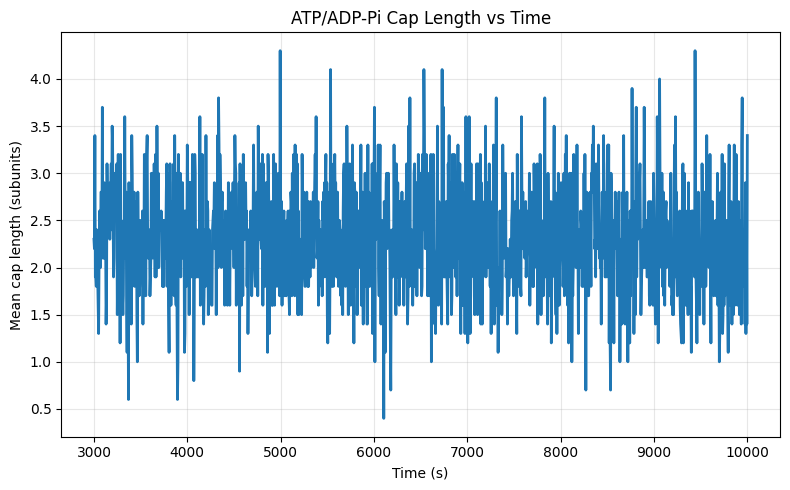

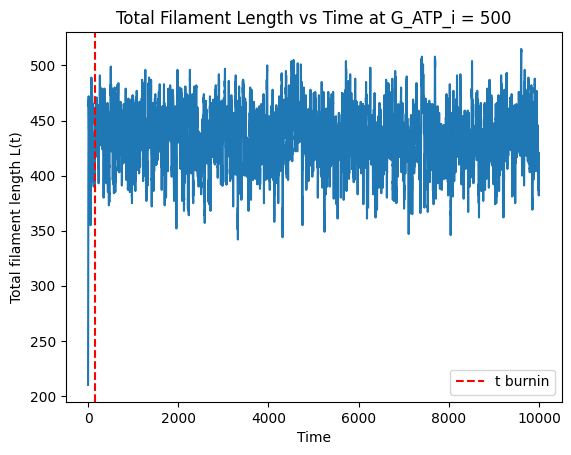

In [19]:
import matplotlib.pyplot as plt


def plot_L_t(t_trace, L_trace, G_ATP_i, t_burnin=None):
    plt.figure()
    plt.plot(t_trace, L_trace)

    if t_burnin is not None:
        plt.axvline(t_burnin, linestyle="--",label = 't burnin', color="red")

    plt.xlabel("Time")
    plt.ylabel("Total filament length L(t)")
    plt.title(f"Total Filament Length vs Time at G_ATP_i = {G_ATP_i}")
    plt.legend()
    plt.show()
import numpy as np
import matplotlib.pyplot as plt

results = run_simulation(*params)

cap_trace = results[6]

# reconstruct times from the recording schedule
t_burnin = 0.3 * params[0]      # params[0] = t_end
record_interval_c = 5

cap_times = t_burnin + record_interval_c * np.arange(len(cap_trace))

plt.figure(figsize=(8,5))
plt.plot(cap_times, cap_trace, lw=2)

plt.xlabel("Time (s)")
plt.ylabel("Mean cap length (subunits)")
plt.title("ATP/ADP-Pi Cap Length vs Time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plot_L_t(results[9],results[8],500,0.3*500)


In [25]:
import matplotlib.pyplot as plt

params_equilibrium = [10000, 11.6, 1.3, 1.4, 0.8, 0.2, 0.1, 7.2, 0.3, 0.1, 0.3, 0.008, 3, 500, 0, 1000] ##equilibrium##
params_explosion = [500, 20.6, 5.5, 0.04, 0.03, 0.02, 0.01, 0.02, 0.03, 0.1, 0.3, 0.002, 1e-7, 5000, 0, 10000] ##explosion##
params_implosion = [500, 7.6, 2.5, 4, 0.3, 2, 5, 3, 0.8, 0.1, 0.3, 0.002, 1e-7, 5000, 0, 10000] ##implosion##

# Run each parameter set
eq_results = run_simulation(*params_equilibrium)
ex_results = run_simulation(*params_explosion)
im_results = run_simulation(*params_implosion)

# Extract traces
t_eq, L_eq = eq_results[9], eq_results[8]
t_ex, L_ex = ex_results[9], ex_results[8]
t_im, L_im = im_results[9], im_results[8]

# Plot
plt.figure(figsize=(8,6))

plt.plot(t_eq, L_eq, label="Equilibrium")
plt.plot(t_ex, L_ex, label="Explosion")
plt.plot(t_im, L_im, label="Implosion")

plt.xlabel("Time")
plt.ylabel("Total Filament Length")
plt.title("Actin Filament Length vs Time")
plt.legend()
plt.grid(True)

plt.show()

KeyboardInterrupt: 

In [ ]:
r1 #[s**-1]on+ ATP
r2 #[s**-1]on- ATP
r3 #[s**-1]off+ ATP
r4 #[s**-1]off- ATP
r5 #[s**-1]off+ ADP-Pi
r6 #[s**-1]off- ADP-Pi
r7 #[s**-1]off+ ADP
r8 #[s**-1]off- ADP


r_exch #[s**-1] ADP-ATP exchange rate
r_hydrol #[s**-1] ATP Hydrolysis rate
r_pi_rel #[s**-1] Pi Release Rate


r_nuc #Nucleation rate


G_ATP_i # Number of initial ATP G-Actin in solution
G_ADP_i # Number of initial ADP G-Actin in solution
vol #volume of 'pool'

t_end #length of simulation [s]




In [ ]:
        K1 = (3.5 * (1.2-11) * (10**6))/(0.041 * (0.036-0.047))
        K2 = (13 *(4.0-40) * (10**5))/(22 *(19-25))



        k_nuc = *(C**4)